# CLUTRR Crisp-Gold Calibration Anchor — Dataset Builder Demo

**Artifact:** *CLUTRR Crisp-Gold Calibration Anchor: Atomic + Multi-Hop Kinship Triples*

This dataset is the **crisp-gold calibration anchor** for a neuro-symbolic
text→logic hallucination-control experiment. CLUTRR (Sinha et al., EMNLP 2019,
[arXiv:1908.06177](https://arxiv.org/abs/1908.06177)) is rule-based / templated, so its
kinship gold is **exact** (no annotation noise) — exactly the property needed to host a
realized-FDR-vs-α calibration diagonal.

`data.py` reads raw CLUTRR TEST rows and **standardizes** each story into one example with:

- **atomic_facts** — the `k` directly-stated chain edges (the "too clean" atomic family),
- **multi_hop_facts** — the `k-1` proof-state-derived *inferred* relations incl. the query target
  (the error-dense "populable" family the disconfirmation is registered on),
- a **kinship_edge_graph** and flat `metadata_*` fields (fold `k2..k10`, difficulty split, etc.).

Everything is derived **deterministically from CLUTRR's own structured fields**
(`proof_state`, `story_edges`, `edge_types`, `genders`) — no rule reimplementation, no LLM.

**This demo** loads a small curated set of **raw CLUTRR rows** and runs the *exact*
`build_record` / `to_example` pipeline from `data.py` on them: parse → crisp simple-path
filter → seeded stratified confirmatory/pilot split → round-robin interleave → standardized
examples. The full build does this over ~2191 pooled rows to emit 190 documents; here we use
a 36-row subset (k=2..10) so it runs in seconds.

## Setup — install dependencies

`loguru` is not pre-installed on Colab, so it is always installed. The plotting/table
packages (`numpy`, `matplotlib`, `tabulate`) are pre-installed on Colab; we install them
locally at Colab's exact versions so a local run mirrors the Colab environment.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, install everywhere (matches pyproject.toml pin)
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab; install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


## Imports

The original `data.py` import block, minus infra-only pieces (`argparse`, `resource`,
`psutil`, `csv`) that the notebook does not need: there is no CLI here, no RAM-guard
(this is a 36-row CPU task), and the raw rows are loaded from JSON instead of CSV.
Logging is configured to stdout only (the original also wrote a rotating file log).

In [2]:
import ast
import json
import re
import random
import sys
from collections import Counter, defaultdict

from loguru import logger

# notebook-friendly logging: stdout only (original also added a rotating logs/data.log)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data loading

Loads the curated demo subset (`mini_demo_data.json`) from GitHub, falling back to a local
file so the notebook runs both in Colab (after deployment) and locally (now). The file holds
**raw CLUTRR rows** — the actual input to `data.py` — each with its original CSV fields plus
`_source_config`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"\nLoaded {len(data['raw_clutrr_rows'])} raw CLUTRR rows")
print("Row fields:", list(data["raw_clutrr_rows"][0].keys()))

Curated demo subset of RAW CLUTRR v1 TEST rows (input to data.py), 36 rows spanning chain length k=2..10, 4 per k. Each row keeps its original CSV fields plus _source_config; the notebook runs the real build_record/to_example standardization pipeline on them.

Loaded 36 raw CLUTRR rows
Row fields: ['', 'id', 'story', 'query', 'target', 'target_text', 'clean_story', 'proof_state', 'f_comb', 'task_name', 'story_edges', 'edge_types', 'query_edge', 'genders', 'task_split', '_source_config']


## Config — tunable parameters

All tunable knobs in one place. The demo uses **small per-fold counts** so it runs on the
36-row subset; the full builder's true per-`k` distributions are kept commented for reference.
Scale `N_CONFIRM_PER_K` / `N_PILOT_PER_K` up (the curated subset has 4 rows per `k`) to draw
more documents per fold.

In [5]:
SEED = 20240617                                   # reproducible stratified sampling
DATASET_NAME = "CLUTRR-v1-CrispGold-CalibrationAnchor"
KS = list(range(2, 11))                           # chain lengths k = 2..10

# --- Full-build per-fold distributions (190-doc run), kept for reference ----------
# CONFIRM_COUNTS = {2: 12, 3: 15, 4: 20, 5: 20, 6: 20, 7: 18, 8: 18, 9: 15, 10: 12}  # ~150
# PILOT_COUNTS   = {2: 5,  3: 5,  4: 5,  5: 5,  6: 5,  7: 5,  8: 5,  9: 3,  10: 2}    # ~40
# --- Demo: small per-fold counts over the 36-row subset (4 rows available per k) --
N_CONFIRM_PER_K = 2                               # confirmatory docs drawn per fold
N_PILOT_PER_K   = 1                               # DISJOINT pilot docs drawn per fold
CONFIRM_COUNTS = {k: N_CONFIRM_PER_K for k in KS}
PILOT_COUNTS   = {k: N_PILOT_PER_K   for k in KS}

# Round-robin k order that alternates short/long so the output spans both families.
K_ORDER = [2, 10, 6, 3, 9, 7, 4, 8, 5]

## Parsing helpers (verbatim from `data.py`)

These turn CLUTRR's structured fields into Python objects. `parse_proof_state` reads the
python-repr proof tree and separates **leaf** triples (the atomic facts) from **derived**
triples (the inferred multi-hop facts) and finds the single proof **root** (= query target).
`path_len` counts how many atomic edges a derived triple spans; `strip_brackets` removes
CLUTRR's `[Name]` entity-span markers to recover clean prose.

In [6]:
def parse_proof_state(ps_str: str):
    """Parse CLUTRR proof_state (python-repr string of list-of-tuple-keyed-dicts).

    Returns (derived_order, leaf_facts, root, derived_children):
      - derived_order: list of derived (head, rel, tail) triples = dict keys (order preserved)
      - leaf_facts:    child triples never used as a key  (the atomic facts)
      - root:          the single derived triple never used as a child (== query target), else None
      - derived_children: {derived_triple: [child triple, child triple]}
    """
    ps = ast.literal_eval(ps_str)
    derived_order: list[tuple] = []
    children_all: list[tuple] = []
    derived_children: dict[tuple, list[tuple]] = {}
    for d in ps:
        for key, val in d.items():
            derived_order.append(key)
            derived_children[key] = list(val)
            children_all.extend(val)
    keyset = set(derived_order)
    childset = set(children_all)
    leaf = [c for c in dict.fromkeys(children_all) if c not in keyset]
    roots = [k for k in derived_order if k not in childset]
    root = roots[0] if len(roots) == 1 else None
    return derived_order, leaf, root, derived_children


def parse_genders(genders_raw: str):
    """'Name:gender,Name:gender,...' -> (ordered_names, name->gender map)."""
    order: list[str] = []
    gmap: dict[str, str] = {}
    for pair in genders_raw.split(","):
        name, gender = pair.rsplit(":", 1)
        order.append(name)
        gmap[name] = gender
    return order, gmap


def path_len(triple, derived_children, memo):
    """Number of atomic (leaf) edges spanned by a derived triple's proof subtree."""
    if triple not in derived_children:
        return 1  # leaf atomic fact
    if triple in memo:
        return memo[triple]
    total = sum(path_len(c, derived_children, memo) for c in derived_children[triple])
    memo[triple] = total
    return total


def strip_brackets(text: str) -> str:
    """Remove CLUTRR's [Name] entity-span markers, leaving clean prose."""
    return re.sub(r"[\[\]]", "", text)

## `build_record` — parse one CLUTRR row into a record (verbatim from `data.py`)

Applies the **crisp simple-path invariants** (distinct entities `== k+1`, distinct edges,
`|atomic| == k`, `|multi_hop| == k-1`, exactly one proof root equal to the query target, and a
genders-order node→name map that reproduces the proof_state atomic leaves). Rows that fail any
invariant are rejected (logged, not raised), guaranteeing deterministic crisp gold.

In [7]:
def build_record(row: dict, config: str):
    """Parse one CLUTRR CSV row into a parsed record dict, or None if it fails the
    crisp simple-path invariants. Logs (does not raise) on rejection."""
    clutrr_id = row["id"]
    try:
        edge_types = ast.literal_eval(row["edge_types"])
        story_edges = [tuple(e) for e in ast.literal_eval(row["story_edges"])]
        query = tuple(ast.literal_eval(row["query"]))
        target_text = row["target_text"]
        f_comb = row["f_comb"]
        task_name = row["task_name"]
        clean_story = row.get("clean_story") or row.get("story") or ""
        noisy_story = row.get("story") or clean_story
        gorder, gmap = parse_genders(row["genders"])
        derived_order, leaf, root, derived_children = parse_proof_state(row["proof_state"])
    except (ValueError, SyntaxError, KeyError) as exc:
        logger.debug(f"[{clutrr_id}] parse failure: {exc}")
        return None

    k = len(edge_types)
    if not clean_story:
        return None

    # --- Crisp simple-path invariants (canonical clean CLUTRR chain) --------- #
    nodes_used = sorted({i for e in story_edges for i in e})
    simple_path = (
        len(nodes_used) == k + 1
        and nodes_used == list(range(k + 1))
        and len(set(story_edges)) == k
    )
    if not simple_path:
        return None
    # k cross-check three ways (Step 3): len(edge_types)==len(f_comb)==task_name k
    if not (len(edge_types) == len(f_comb.split("-")) == int(task_name.split(".")[-1])):
        return None
    if max(nodes_used) >= len(gorder):
        return None
    # genders-order namemap must reproduce the proof_state atomic (leaf) set
    leafset = set(leaf)
    namemap_ok = all(
        (gorder[i], rel, gorder[j]) in leafset for (i, j), rel in zip(story_edges, edge_types)
    )
    if not namemap_ok:
        return None
    if len(leaf) != k or len(derived_order) != k - 1 or root is None:
        return None
    if root != (query[0], target_text, query[1]):
        return None

    # --- Entities ----------------------------------------------------------- #
    entities = [
        {"name": name, "gender": gmap[name], "type": "person", "node_index": idx}
        for idx, name in enumerate(gorder)
    ]
    all_names = set(gorder)

    # --- Atomic gold (directly-stated, narrative order via story_edges) ------- #
    # (B) from (story_edges, edge_types, namemap); cross-validated against (A) proof_state leaves.
    atomic_facts = [
        {"head": gorder[i], "relation": rel, "tail": gorder[j]}
        for (i, j), rel in zip(story_edges, edge_types)
    ]
    atomic_crosscheck = (
        "match"
        if {(a["head"], a["relation"], a["tail"]) for a in atomic_facts} == leafset
        else "mismatch"
    )

    # --- Multi-hop gold (inferred, from proof_state derived keys; NO rule reimpl) #
    memo: dict[tuple, int] = {}
    multi_hop_facts = []
    for d in derived_order:
        multi_hop_facts.append(
            {
                "head": d[0],
                "relation": d[1],
                "tail": d[2],
                "derived_from": [list(c) for c in derived_children[d]],
                "path_len": path_len(d, derived_children, memo),
                "is_query_target": d == root,
            }
        )
    # build-up order: smallest compositions first, query target (path_len==k) last
    multi_hop_facts.sort(key=lambda m: (m["path_len"], not m["is_query_target"]))

    mh_query_target = {"head": query[0], "relation": target_text, "tail": query[1]}

    # --- Kinship edge graph ------------------------------------------------- #
    kinship_edge_graph = {
        "nodes": [
            {"index": i, "name": gorder[i], "gender": gmap[gorder[i]]}
            for i in range(len(gorder))
        ],
        "edges": [
            {"src": i, "dst": j, "relation": rel}
            for (i, j), rel in zip(story_edges, edge_types)
        ],
    }

    # --- Integrity: every fact name must be a known entity ------------------ #
    fact_names = set()
    for f in atomic_facts + multi_hop_facts + [mh_query_target]:
        fact_names.add(f["head"])
        fact_names.add(f["tail"])
    if not fact_names <= all_names:
        logger.debug(f"[{clutrr_id}] fact name not in entities")
        return None

    document_text = strip_brackets(clean_story)
    relations = sorted({f["relation"] for f in atomic_facts + multi_hop_facts})

    input_obj = {
        "doc_id": clutrr_id,
        "document_text": document_text,
        "document_text_bracketed": clean_story,
        "entities": entities,
        "query": {"head": query[0], "tail": query[1]},
    }
    output_obj = {
        "atomic_facts": atomic_facts,
        "multi_hop_facts": multi_hop_facts,
        "multi_hop_query_target": mh_query_target,
        "kinship_edge_graph": kinship_edge_graph,
    }

    return {
        "k": k,
        "clutrr_id": clutrr_id,
        "config": config,
        "input_obj": input_obj,
        "output_obj": output_obj,
        "f_comb": f_comb,
        "task_name": task_name,
        "n_atomic": len(atomic_facts),
        "n_multi_hop": len(multi_hop_facts),
        "doc_char_len": len(document_text),
        "proof_state_raw": row["proof_state"],
        "noisy_story": noisy_story,
        "atomic_crosscheck": atomic_crosscheck,
        "relations": relations,
    }

## `to_example` — render a record as a schema-compliant row (verbatim from `data.py`)

`input` and `output` are JSON-serialized strings (parse with `json.loads`); everything else is
a flat `metadata_*` field. Row == one CLUTRR story == one example.

In [8]:
def to_example(rec: dict, is_pilot: bool) -> dict:
    """Render a parsed record into a schema-compliant example row (row == example)."""
    k = rec["k"]
    return {
        "input": json.dumps(rec["input_obj"], ensure_ascii=False),
        "output": json.dumps(rec["output_obj"], ensure_ascii=False),
        "metadata_fold": f"k{k}",
        "metadata_chain_length_k": k,
        "metadata_difficulty_split": "short" if k <= 3 else "long",
        "metadata_f_comb": rec["f_comb"],
        "metadata_task_name": rec["task_name"],
        "metadata_source_config": rec["config"],
        "metadata_source_split": "test",
        "metadata_clutrr_id": rec["clutrr_id"],
        "metadata_is_pilot": is_pilot,
        "metadata_n_atomic_facts": rec["n_atomic"],
        "metadata_n_multi_hop_facts": rec["n_multi_hop"],
        "metadata_document_char_length": rec["doc_char_len"],
        "metadata_proof_state_raw": rec["proof_state_raw"],
        "metadata_noisy_story": rec["noisy_story"],
        "metadata_atomic_crosscheck": rec["atomic_crosscheck"],
        "metadata_namemap_method": "genders_order",
        "metadata_genders_order_valid": True,
        "metadata_relation_vocab_version": "clutrr_kinship",
    }

## Step 1 — pool the raw rows, dedup by clean story

The full builder pools both CLUTRR TEST configs and dedups by `clean_story`; here the curated
subset is already pooled, so this step just mirrors that dedup and tallies rows per source config.

In [9]:
rng = random.Random(SEED)

# 1) Pool the curated raw rows, dedup by clean_story (mirrors the original CSV pooling).
pool: dict = {}
raw_counts = Counter()
for r in data["raw_clutrr_rows"]:
    config = r["_source_config"]
    raw_counts[config] += 1
    cs = r.get("clean_story") or r.get("story") or ""
    if cs and cs not in pool:
        pool[cs] = (r, config)
logger.info(f"Pooled deduped rows: {len(pool)}")

13:23:47|INFO   |Pooled deduped rows: 36


## Step 2 — parse & filter to crisp simple-path records

Run `build_record` on every pooled row; rows that violate the simple-path invariants are
rejected. The survivors are grouped by chain length `k` (the calibration folds).

In [10]:
# 2) Parse + filter to crisp simple-path records.
clean: list = []
n_rejected = 0
for cs, (r, config) in pool.items():
    rec = build_record(r, config)
    if rec is None:
        n_rejected += 1
        continue
    clean.append(rec)
logger.info(f"Clean simple-path records: {len(clean)} (rejected {n_rejected})")

clean_by_k: dict = defaultdict(list)
for rec in clean:
    clean_by_k[rec["k"]].append(rec)
logger.info("Clean k-distribution: " + ", ".join(f"k{k}={len(clean_by_k[k])}" for k in sorted(clean_by_k)))

13:23:47|INFO   |Clean simple-path records: 36 (rejected 0)


13:23:47|INFO   |Clean k-distribution: k2=4, k3=4, k4=4, k5=4, k6=4, k7=4, k8=4, k9=4, k10=4


## Step 3 — seeded stratified sampling (confirmatory + DISJOINT pilot)

Within each fold, deterministically order by id, seed-shuffle, then take `CONFIRM_COUNTS[k]`
confirmatory docs and a **disjoint** `PILOT_COUNTS[k]` pilot docs. The assert guarantees the
two id sets never overlap.

In [11]:
# 3) Seeded stratified sampling: confirmatory + DISJOINT pilot.
confirm_by_k: dict = {}
pilot_by_k: dict = {}
for k in sorted(clean_by_k):
    bucket = sorted(clean_by_k[k], key=lambda x: x["clutrr_id"])  # deterministic pre-shuffle order
    rng.shuffle(bucket)
    n_conf = CONFIRM_COUNTS.get(k, 0)
    n_pilot = PILOT_COUNTS.get(k, 0)
    if len(bucket) < n_conf + n_pilot:
        logger.warning(f"k={k}: only {len(bucket)} available for {n_conf}+{n_pilot} requested")
    confirm_by_k[k] = bucket[:n_conf]
    pilot_by_k[k] = bucket[n_conf : n_conf + n_pilot]

confirm_ids = {rec["clutrr_id"] for recs in confirm_by_k.values() for rec in recs}
pilot_ids = {rec["clutrr_id"] for recs in pilot_by_k.values() for rec in recs}
assert confirm_ids.isdisjoint(pilot_ids), "confirmatory and pilot overlap!"
logger.info(f"Confirmatory={len(confirm_ids)} Pilot={len(pilot_ids)}")

13:23:47|INFO   |Confirmatory=18 Pilot=9


## Step 4 — round-robin interleave into examples

Interleave folds by `K_ORDER` (alternating short/long chains) and render each record into a
schema-compliant example via `to_example`, tagging pilot rows.

In [12]:
# 4) Round-robin interleave by K_ORDER so the output spans short+long chains.
queues = {k: list(confirm_by_k.get(k, [])) + list(pilot_by_k.get(k, [])) for k in clean_by_k}
examples: list = []
remaining = True
while remaining:
    remaining = False
    for k in K_ORDER:
        q = queues.get(k)
        if q:
            rec = q.pop(0)
            examples.append(to_example(rec, is_pilot=rec["clutrr_id"] in pilot_ids))
            remaining = True
logger.info(f"Total examples={len(examples)}")

13:23:47|INFO   |Total examples=27


## Step 5 — aggregate top-level metadata & assemble output

Assemble the standardized dataset object: a `metadata` block (provenance, k-distributions,
relation vocabulary) plus a single `datasets` group holding the example rows — the same shape
`data.py` writes to `full_data_out.json`.

In [13]:
# 5) Aggregate metadata.
conf_k_dist = {f"k{k}": len(confirm_by_k.get(k, [])) for k in sorted(clean_by_k)}
pilot_k_dist = {f"k{k}": len(pilot_by_k.get(k, [])) for k in sorted(clean_by_k)}
relation_vocab = sorted({rel for rec in clean for rel in rec["relations"]})
logger.info(f"Confirmatory k-dist: {conf_k_dist}")
logger.info(f"Pilot k-dist: {pilot_k_dist}")
logger.info(f"Relation vocabulary ({len(relation_vocab)}): {relation_vocab}")

out = {
    "metadata": {
        "selected_best_dataset": DATASET_NAME,
        "seed": SEED,
        "raw_rows_per_config": dict(raw_counts),
        "pooled_deduped_rows": len(pool),
        "clean_simple_path_records": len(clean),
        "rejected_non_simple_path": n_rejected,
        "clean_k_distribution": {f"k{k}": len(clean_by_k[k]) for k in sorted(clean_by_k)},
        "confirmatory_count": len(confirm_ids),
        "pilot_count": len(pilot_ids),
        "total_documents": len(examples),
        "confirmatory_k_distribution": conf_k_dist,
        "pilot_k_distribution": pilot_k_dist,
        "relation_vocabulary": relation_vocab,
        "relation_vocab_version": "clutrr_kinship",
    },
    "datasets": [
        {
            "dataset": DATASET_NAME,
            "examples": examples,
        }
    ],
}
print(f"\nBuilt standardized dataset: {len(examples)} examples under '{DATASET_NAME}'")

13:23:47|INFO   |Confirmatory k-dist: {'k2': 2, 'k3': 2, 'k4': 2, 'k5': 2, 'k6': 2, 'k7': 2, 'k8': 2, 'k9': 2, 'k10': 2}


13:23:47|INFO   |Pilot k-dist: {'k2': 1, 'k3': 1, 'k4': 1, 'k5': 1, 'k6': 1, 'k7': 1, 'k8': 1, 'k9': 1, 'k10': 1}


13:23:47|INFO   |Relation vocabulary (16): ['aunt', 'brother', 'daughter', 'father', 'granddaughter', 'grandfather', 'grandmother', 'grandson', 'husband', 'mother', 'nephew', 'niece', 'sister', 'son', 'uncle', 'wife']



Built standardized dataset: 27 examples under 'CLUTRR-v1-CrispGold-CalibrationAnchor'


## Results — summary table, one parsed example, and the fold split

We print a per-fold table (clean rows available vs. confirmatory/pilot drawn), inspect one
standardized example end-to-end (parsing its `input`/`output` JSON strings back into atomic +
multi-hop gold), and chart the stratified split by fold.

| fold   | difficulty   |   clean_avail |   confirm |   pilot |
|--------|--------------|---------------|-----------|---------|
| k2     | short        |             4 |         2 |       1 |
| k3     | short        |             4 |         2 |       1 |
| k4     | long         |             4 |         2 |       1 |
| k5     | long         |             4 |         2 |       1 |
| k6     | long         |             4 |         2 |       1 |
| k7     | long         |             4 |         2 |       1 |
| k8     | long         |             4 |         2 |       1 |
| k9     | long         |             4 |         2 |       1 |
| k10    | long         |             4 |         2 |       1 |

TOTAL  clean=36  confirm=18  pilot=9  examples=27
relation vocabulary (16): ['aunt', 'brother', 'daughter', 'father', 'granddaughter', 'grandfather', 'grandmother', 'grandson', 'husband', 'mother', 'nephew', 'niece', 'sister', 'son', 'uncle', 'wife']

=== Example 0c69eebf-79bf-4836-b21a-558516e

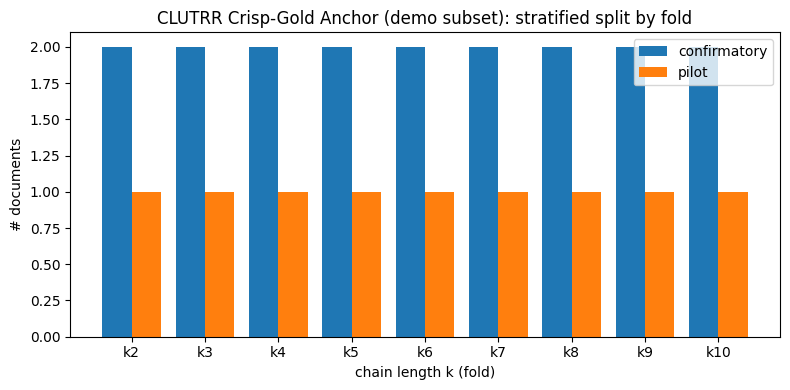

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

ks = sorted(clean_by_k)
rows_tbl = [[f"k{k}", "short" if k <= 3 else "long", len(clean_by_k[k]),
             len(confirm_by_k.get(k, [])), len(pilot_by_k.get(k, []))] for k in ks]
print(tabulate(rows_tbl, headers=["fold", "difficulty", "clean_avail", "confirm", "pilot"],
               tablefmt="github"))
print(f"\nTOTAL  clean={len(clean)}  confirm={len(confirm_ids)}  "
      f"pilot={len(pilot_ids)}  examples={len(examples)}")
print(f"relation vocabulary ({len(relation_vocab)}): {relation_vocab}")

# --- Inspect one standardized example end-to-end (gold parsed back from JSON strings) ---
ex = out["datasets"][0]["examples"][0]
inp = json.loads(ex["input"])
gold = json.loads(ex["output"])
print(f"\n=== Example {ex['metadata_clutrr_id']}  "
      f"(fold {ex['metadata_fold']}, {ex['metadata_difficulty_split']}, "
      f"pilot={ex['metadata_is_pilot']}) ===")
print("DOC  :", inp["document_text"])
print("QUERY:", inp["query"]["head"], "-> ?", "->", inp["query"]["tail"])
print("ATOMIC facts (directly stated in text):")
for f in gold["atomic_facts"]:
    print(f"    {f['head']} --{f['relation']}--> {f['tail']}")
print("MULTI-HOP facts (inferred via proof state):")
for f in gold["multi_hop_facts"]:
    tag = "  <-- QUERY TARGET" if f["is_query_target"] else ""
    print(f"    {f['head']} --{f['relation']}--> {f['tail']}  (path_len={f['path_len']}){tag}")

# --- Bar chart: confirmatory vs pilot per fold ---
x = np.arange(len(ks))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, [len(confirm_by_k.get(k, [])) for k in ks], 0.4, label="confirmatory")
plt.bar(x + 0.2, [len(pilot_by_k.get(k, [])) for k in ks], 0.4, label="pilot")
plt.xticks(x, [f"k{k}" for k in ks])
plt.xlabel("chain length k (fold)")
plt.ylabel("# documents")
plt.title("CLUTRR Crisp-Gold Anchor (demo subset): stratified split by fold")
plt.legend()
plt.tight_layout()
plt.show()